<a href="https://colab.research.google.com/github/shrinzzzz/smart-patient-vital-anomaly-detector/blob/main/01_vital_sign_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Smart Patient Vital-Sign Anomaly Detector

### Mini Project 1 — Biomedical AI

**Objective:**  
Develop a system that detects unusual physiological patterns
in patient vital-sign time-series data.

### Technologies
- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Streamlit

### Dataset
VitalDB Open Dataset

> This project is an educational/research prototype.
> It is not intended for clinical diagnosis or medical decision-making.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully! 🫀")

Libraries loaded successfully! 🫀


In [ ]:
import requests
from io import BytesIO

url = "https://api.vitaldb.net/cases.csv.gz"

response = requests.get(url)

print("Status code:", response.status_code)
print("Data downloaded:", len(response.content), "bytes")

Status code: 200
Downloaded: 2199564 bytes


In [ ]:
cases = pd.read_csv(
    BytesIO(response.content)
)

print("Number of cases:", len(cases))
print("Number of variables:", len(cases.columns))

cases.head()

Number of cases: 6388
Number of variables: 74


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


In [ ]:
# Show all available VitalDB track names

tracks_url = "https://api.vitaldb.net/trks"

tracks_response = requests.get(tracks_url)

print("Status code:", tracks_response.status_code)
print("Downloaded:", len(tracks_response.content), "bytes")

Status code: 200
Downloaded: 30565770 bytes


Number of track records: 486449
Number of columns: 3


,caseid,tname,tid
0,1,BIS/BIS,fd869e25ba82a66cc95b38ed47110bf4f14bb368
1,1,BIS/EEG1_WAV,0aa685df768489a18a5e9f53af0d83bf60890c73
2,1,BIS/EEG2_WAV,ad13b2c39b19193c8ae4a2de4f8315f18d61a57e
3,1,BIS/EMG,2525603efe18d982764dbca457affe7a45e766a9
4,1,BIS/SEF,1c91aec859304840dec75acf4a35da78be0e8ef0


In [ ]:
# Load the VitalDB track information

if tracks_response.content[:2] == b'\x1f\x8b':
    tracks = pd.read_csv(
        BytesIO(tracks_response.content),
        compression="gzip"
    )
else:
    tracks = pd.read_csv(
        BytesIO(tracks_response.content)
    )

print("Number of track records:", len(tracks))
print("Number of columns:", len(tracks.columns))

tracks.head()

Number of track records: 486449
Number of columns: 3


,caseid,tname,tid
0,1,BIS/BIS,fd869e25ba82a66cc95b38ed47110bf4f14bb368
1,1,BIS/EEG1_WAV,0aa685df768489a18a5e9f53af0d83bf60890c73
2,1,BIS/EEG2_WAV,ad13b2c39b19193c8ae4a2de4f8315f18d61a57e
3,1,BIS/EMG,2525603efe18d982764dbca457affe7a45e766a9
4,1,BIS/SEF,1c91aec859304840dec75acf4a35da78be0e8ef0


In [ ]:
# Search for important vital-sign tracks

keywords = ["HR", "PLETH", "SPO2", "ART", "NIBP", "TEMP", "ECG"]

vital_tracks = tracks[
    tracks["tname"].str.upper().str.contains(
        "|".join(keywords),
        na=False
    )
]

print("Matching track records:", len(vital_tracks))

print(
    vital_tracks[["caseid", "tname"]]
    .drop_duplicates()
    .head(100)
    .to_string(index=False)
)

Matching track records: 67879
 caseid                tname
      1           SNUADC/ART
      1        SNUADC/ECG_II
      1        SNUADC/ECG_V5
      1         SNUADC/PLETH
      1    Solar8000/ART_DBP
      1    Solar8000/ART_MBP
      1    Solar8000/ART_SBP
      1         Solar8000/HR
      1   Solar8000/NIBP_DBP
      1   Solar8000/NIBP_MBP
      1   Solar8000/NIBP_SBP
      1   Solar8000/PLETH_HR
      1 Solar8000/PLETH_SPO2
      2        SNUADC/ECG_II
      2        SNUADC/ECG_V5
      2         SNUADC/PLETH
      2         Solar8000/HR
      2   Solar8000/NIBP_DBP
      2   Solar8000/NIBP_MBP
      2   Solar8000/NIBP_SBP
      2   Solar8000/PLETH_HR
      2 Solar8000/PLETH_SPO2
      3           SNUADC/ART
      3        SNUADC/ECG_II
      3        SNUADC/ECG_V5
      3         SNUADC/PLETH
      3    Solar8000/ART_DBP
      3    Solar8000/ART_MBP
      3    Solar8000/ART_SBP
      3         Solar8000/HR
      3   Solar8000/NIBP_DBP
      3   Solar8000/NIBP_MBP
      3   Sol

In [ ]:
# Find cases containing all four vital-sign tracks

required_tracks = [
    "Solar8000/HR",
    "Solar8000/PLETH_SPO2",
    "Solar8000/NIBP_SBP",
    "Solar8000/NIBP_DBP"
]

# Find cases that contain each required track
cases_with_all_vitals = (
    tracks[tracks["tname"].isin(required_tracks)]
    .groupby("caseid")["tname"]
    .nunique()
)

cases_with_all_vitals = cases_with_all_vitals[
    cases_with_all_vitals == len(required_tracks)
]

print("Cases containing all 4 vital signs:", len(cases_with_all_vitals))

print("\nFirst 20 suitable case IDs:")
print(cases_with_all_vitals.head(20))

Cases containing all 4 vital signs: 5751

First 20 suitable case IDs:
caseid
1     4
2     4
3     4
5     4
6     4
8     4
9     4
10    4
11    4
12    4
14    4
15    4
16    4
17    4
18    4
19    4
20    4
21    4
22    4
23    4
Name: tname, dtype: int64


In [ ]:
# Find vital-sign related tracks

keywords = ["HR", "PLETH", "SPO2", "ART", "NIBP", "TEMP", "ECG"]

vital_tracks = tracks[
    tracks["tname"].str.upper().str.contains(
        "|".join(keywords),
        na=False
    )
]

# Get unique track names
selected_tracks = (
    vital_tracks["tname"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Number of matching records:", len(vital_tracks))
print("\nAvailable vital-sign tracks:\n")

for track in selected_tracks:
    print("-", track)

Number of matching records: 67879

Available vital-sign tracks:

- CardioQ/HR
- EV1000/ART_MBP
- FMS/INPUT_AMB_TEMP
- FMS/INPUT_TEMP
- FMS/OUTPUT_AMB_TEMP
- FMS/OUTPUT_TEMP
- SNUADC/ART
- SNUADC/ECG_II
- SNUADC/ECG_V5
- SNUADC/PLETH
- Solar8000/ART_DBP
- Solar8000/ART_MBP
- Solar8000/ART_SBP
- Solar8000/HR
- Solar8000/NIBP_DBP
- Solar8000/NIBP_MBP
- Solar8000/NIBP_SBP
- Solar8000/PLETH_HR
- Solar8000/PLETH_SPO2
- Vigilance/HR_AVG


In [2]:
# Reload VitalDB track information

import requests
import pandas as pd
from io import BytesIO

tracks_url = "https://api.vitaldb.net/trks"
tracks_response = requests.get(tracks_url)

print("Status code:", tracks_response.status_code)

# Load CSV whether compressed or uncompressed
if tracks_response.content[:2] == b'\x1f\x8b':
    tracks = pd.read_csv(
        BytesIO(tracks_response.content),
        compression="gzip"
    )
else:
    tracks = pd.read_csv(
        BytesIO(tracks_response.content)
    )

print("Track records:", len(tracks))
print("Columns:", list(tracks.columns))

Status code: 200
Track records: 486449
Columns: ['caseid', 'tname', 'tid']


In [3]:
selected_tracks = [
    "Solar8000/HR",
    "Solar8000/PLETH_SPO2",
    "Solar8000/NIBP_MBP",
    "FMS/OUTPUT_TEMP"
]

# Find cases that contain all 4 selected signals
case_counts = (
    tracks[tracks["tname"].isin(selected_tracks)]
    .groupby("caseid")["tname"]
    .nunique()
)

complete_cases = case_counts[
    case_counts == len(selected_tracks)
].index.tolist()

print("Cases containing all 4 vital signs:", len(complete_cases))
print("First 10 case IDs:", complete_cases[:10])

Cases containing all 4 vital signs: 11
First 10 case IDs: [5, 917, 945, 985, 2168, 2326, 2327, 2585, 3188, 3857]


In [4]:
# Install the VitalDB Python library
!pip -q install vitaldb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00


In [5]:
import vitaldb
import numpy as np
import pandas as pd

# Use the first 5 cases containing all 4 vital signs
selected_case_ids = complete_cases[:5]

print("Selected case IDs:", selected_case_ids)

# Vital signs we want
selected_tracks = [
    "Solar8000/HR",
    "Solar8000/PLETH_SPO2",
    "Solar8000/NIBP_MBP",
    "FMS/OUTPUT_TEMP"
]

# Load the first case at 1-second intervals
case_id = selected_case_ids[0]

data = vitaldb.load_case(
    case_id,
    selected_tracks,
    1
)

print("Case:", case_id)
print("Data shape:", data.shape)

data[:10]

Selected case IDs: [5, 917, 945, 985, 2168]
Case: 5
Data shape: (21532, 4)


array([[ nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [102.,  95.,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [102.,  94.,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [103.,  94.,  nan,  nan],
       [ nan,  nan,  nan,  nan],
       [103.,  94.,  nan,  nan]], dtype=float32)

In [6]:
columns = [
    "heart_rate",
    "spo2",
    "mean_bp",
    "temperature"
]

df = pd.DataFrame(data, columns=columns)

# Add time in seconds
df["time_sec"] = np.arange(len(df))

print("Data shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

df.head(10)

Data shape: (21532, 5)

Missing values:
heart_rate     11068
spo2           11282
mean_bp        18047
temperature    18114
time_sec           0
dtype: int64


,heart_rate,spo2,mean_bp,temperature,time_sec
0,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,1
2,NaN,NaN,NaN,NaN,2
3,102.0,95.0,NaN,NaN,3
4,NaN,NaN,NaN,NaN,4
5,102.0,94.0,NaN,NaN,5
6,NaN,NaN,NaN,NaN,6
7,103.0,94.0,NaN,NaN,7
8,NaN,NaN,NaN,NaN,8
9,103.0,94.0,NaN,NaN,9


In [7]:
df.describe()

,heart_rate,spo2,mean_bp,temperature,time_sec
count,10464.000000,10250.000000,3485.000000,3418.000000,21532.000000
mean,85.745125,99.824486,82.079483,37.683296,10765.500000
std,4.579632,1.121359,11.678948,1.685807,6215.897334
min,73.000000,79.000000,64.000000,21.700001,0.000000
25%,83.000000,100.000000,69.000000,37.200001,5382.750000
50%,85.000000,100.000000,84.000000,37.700001,10765.500000
75%,88.000000,100.000000,90.000000,38.799999,16148.250000
max,107.000000,100.000000,99.000000,40.200001,21531.000000


In [8]:
print("Available data percentage:")

for column in columns:
    available = df[column].notna().mean() * 100
    print(f"{column}: {available:.2f}%")

Available data percentage:
heart_rate: 48.60%
spo2: 47.60%
mean_bp: 16.19%
temperature: 15.87%


In [10]:
import matplotlib.pyplot as plt

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

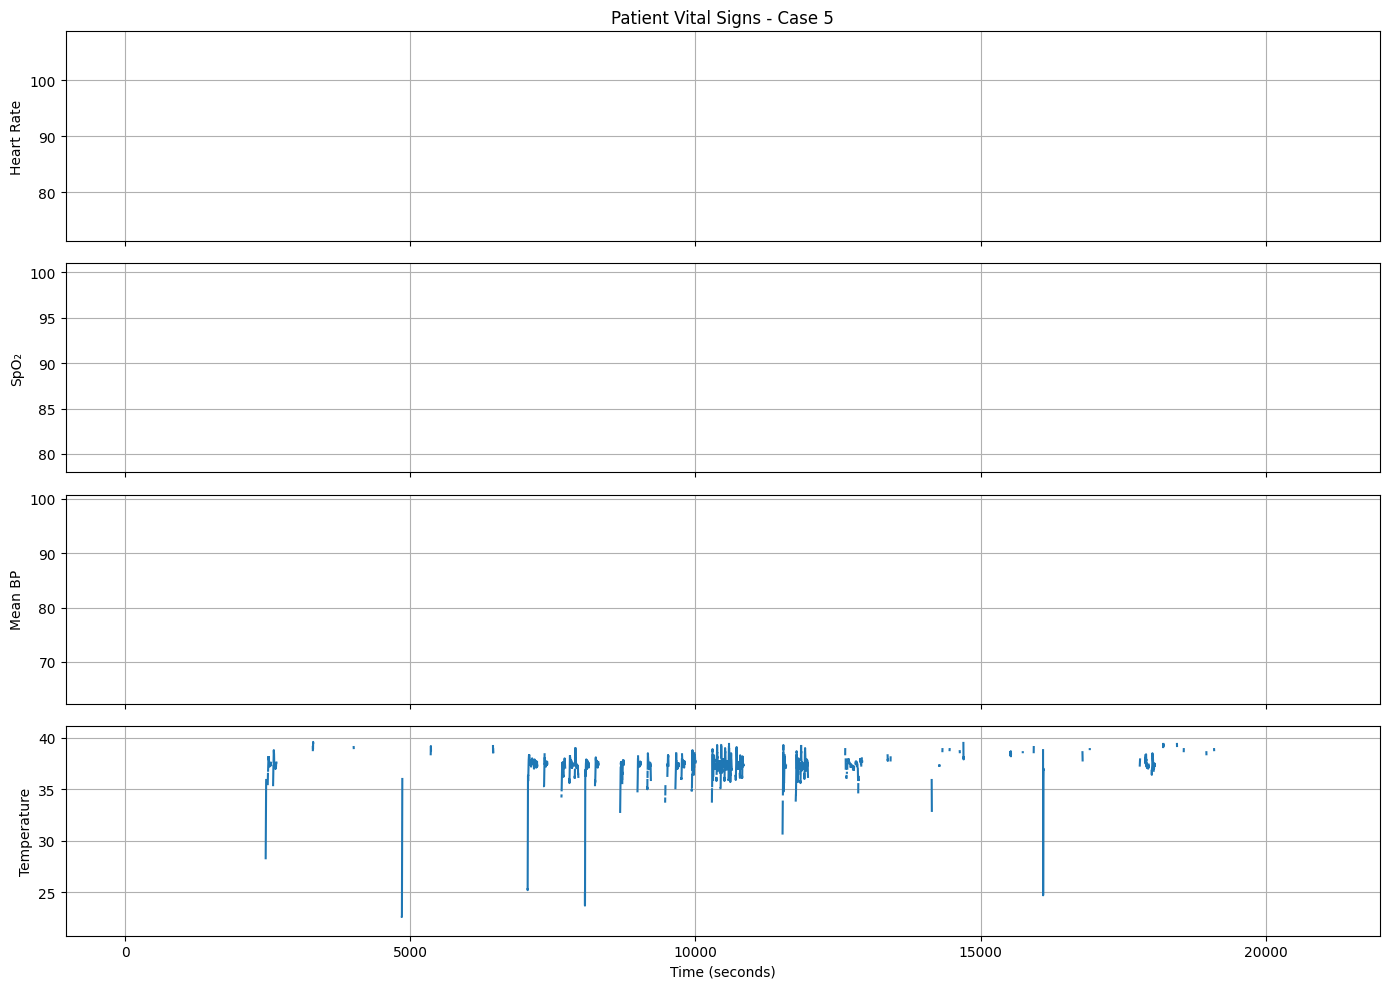

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df["time_sec"], df["heart_rate"])
axes[0].set_ylabel("Heart Rate")
axes[0].set_title("Patient Vital Signs - Case 5")
axes[0].grid(True)

axes[1].plot(df["time_sec"], df["spo2"])
axes[1].set_ylabel("SpO₂")
axes[1].grid(True)

axes[2].plot(df["time_sec"], df["mean_bp"])
axes[2].set_ylabel("Mean BP")
axes[2].grid(True)

axes[3].plot(df["time_sec"], df["temperature"])
axes[3].set_ylabel("Temperature")
axes[3].set_xlabel("Time (seconds)")
axes[3].grid(True)

plt.tight_layout()
plt.show()

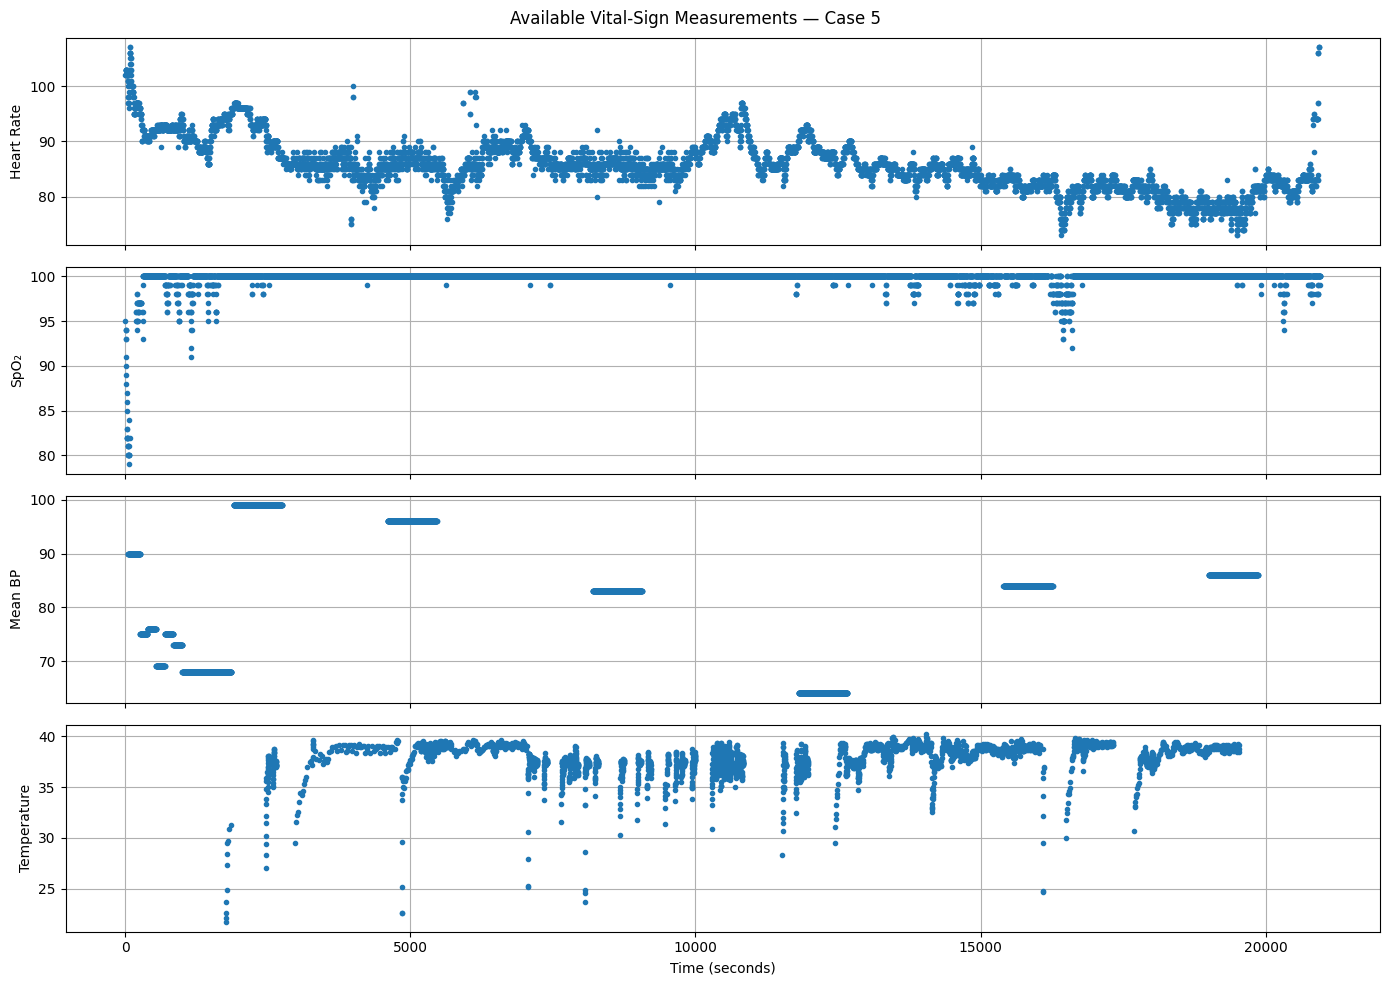

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Heart rate
hr = df.dropna(subset=["heart_rate"])
axes[0].plot(hr["time_sec"], hr["heart_rate"], marker=".", linestyle="None")
axes[0].set_ylabel("Heart Rate")
axes[0].grid(True)

# SpO2
spo2 = df.dropna(subset=["spo2"])
axes[1].plot(spo2["time_sec"], spo2["spo2"], marker=".", linestyle="None")
axes[1].set_ylabel("SpO₂")
axes[1].grid(True)

# Mean BP
bp = df.dropna(subset=["mean_bp"])
axes[2].plot(bp["time_sec"], bp["mean_bp"], marker=".", linestyle="None")
axes[2].set_ylabel("Mean BP")
axes[2].grid(True)

# Temperature
temp = df.dropna(subset=["temperature"])
axes[3].plot(temp["time_sec"], temp["temperature"], marker=".", linestyle="None")
axes[3].set_ylabel("Temperature")
axes[3].set_xlabel("Time (seconds)")
axes[3].grid(True)

fig.suptitle("Available Vital-Sign Measurements — Case 5")
plt.tight_layout()
plt.show()

In [14]:
complete_rows = df.dropna(
    subset=["heart_rate", "spo2", "mean_bp", "temperature"]
)

print("Total rows:", len(df))
print("Rows with all 4 vital signs:", len(complete_rows))
print(
    "Percentage with all 4:",
    f"{len(complete_rows) / len(df) * 100:.2f}%"
)

Total rows: 21532
Rows with all 4 vital signs: 399
Percentage with all 4: 1.85%


In [15]:
complete_rows.head()

,heart_rate,spo2,mean_bp,temperature,time_sec
1763,94.0,100.0,68.0,22.100000,1763
1769,94.0,100.0,68.0,22.600000,1769
1773,94.0,100.0,68.0,23.700001,1773
1787,94.0,100.0,68.0,28.400000,1787
1789,94.0,100.0,68.0,29.500000,1789


In [16]:
print("Usable data combinations for Case 5:\n")

hr_spo2 = df.dropna(subset=["heart_rate", "spo2"])
hr_bp = df.dropna(subset=["heart_rate", "mean_bp"])
hr_temp = df.dropna(subset=["heart_rate", "temperature"])

print("Heart Rate + SpO₂:", len(hr_spo2))
print("Heart Rate + Mean BP:", len(hr_bp))
print("Heart Rate + Temperature:", len(hr_temp))

Usable data combinations for Case 5:

Heart Rate + SpO₂: 10237
Heart Rate + Mean BP: 3485
Heart Rate + Temperature: 1711


In [17]:
print("\nPercentages:")

print(
    "Heart Rate + SpO₂:",
    f"{len(hr_spo2) / len(df) * 100:.2f}%"
)

print(
    "Heart Rate + Mean BP:",
    f"{len(hr_bp) / len(df) * 100:.2f}%"
)

print(
    "Heart Rate + Temperature:",
    f"{len(hr_temp) / len(df) * 100:.2f}%"
)


Percentages:
Heart Rate + SpO₂: 47.54%
Heart Rate + Mean BP: 16.19%
Heart Rate + Temperature: 7.95%


In [18]:
case_summary = []

for cid in selected_case_ids:

    case_data = vitaldb.load_case(
        cid,
        selected_tracks,
        1
    )

    temp_df = pd.DataFrame(
        case_data,
        columns=columns
    )

    hr_spo2_count = temp_df.dropna(
        subset=["heart_rate", "spo2"]
    ).shape[0]

    total_count = len(temp_df)

    case_summary.append({
        "case_id": cid,
        "total_rows": total_count,
        "HR_SpO2_rows": hr_spo2_count,
        "HR_SpO2_percent": (hr_spo2_count / total_count) * 100
    })

case_summary_df = pd.DataFrame(case_summary)

case_summary_df

,case_id,total_rows,HR_SpO2_rows,HR_SpO2_percent
0,5,21532,10237,47.543192
1,917,15980,7633,47.765957
2,945,20403,9668,47.385188
3,985,22631,10989,48.557289
4,2168,32551,15959,49.027680


In [19]:
# Select our main development case
case_id = 2168

data_2168 = vitaldb.load_case(
    case_id,
    selected_tracks,
    1
)

df_2168 = pd.DataFrame(
    data_2168,
    columns=columns
)

df_2168["time_sec"] = np.arange(len(df_2168))

print("Case:", case_id)
print("Data shape:", df_2168.shape)
print("\nMissing values:")
print(df_2168.isna().sum())

Case: 2168
Data shape: (32551, 5)

Missing values:
heart_rate     16579
spo2           16551
mean_bp        28463
temperature    31212
time_sec           0
dtype: int64


In [20]:
df_2168.head(10)

,heart_rate,spo2,mean_bp,temperature,time_sec
0,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,1
2,NaN,NaN,NaN,NaN,2
3,NaN,NaN,NaN,NaN,3
4,95.0,99.0,NaN,NaN,4
5,NaN,NaN,NaN,NaN,5
6,95.0,99.0,NaN,NaN,6
7,NaN,NaN,NaN,NaN,7
8,86.0,99.0,NaN,NaN,8
9,NaN,NaN,NaN,NaN,9


In [21]:
# Create a working dataset using the two best-covered signals

working_df = df_2168[
    ["time_sec", "heart_rate", "spo2"]
].copy()

print("Original rows:", len(working_df))

# Keep only rows where BOTH signals are recorded
working_df = working_df.dropna(
    subset=["heart_rate", "spo2"]
).reset_index(drop=True)

print("Rows with HR + SpO₂:", len(working_df))
print("\nMissing values after filtering:")
print(working_df.isna().sum())

working_df.head(10)

Original rows: 32551
Rows with HR + SpO₂: 15959

Missing values after filtering:
time_sec      0
heart_rate    0
spo2          0
dtype: int64


,time_sec,heart_rate,spo2
0,4,95.0,99.0
1,6,95.0,99.0
2,8,86.0,99.0
3,10,86.0,99.0
4,12,87.0,99.0
5,14,87.0,100.0
6,16,96.0,100.0
7,18,96.0,99.0
8,20,96.0,100.0
9,22,95.0,100.0


In [22]:
working_df.describe()

,time_sec,heart_rate,spo2
count,15959.000000,15959.000000,15959.000000
mean,15974.715020,91.054893,99.998055
std,9222.864563,10.404678,0.045433
min,4.000000,17.000000,98.000000
25%,7988.000000,88.000000,100.000000
50%,15972.000000,93.000000,100.000000
75%,23960.000000,97.000000,100.000000
max,31950.000000,182.000000,100.000000


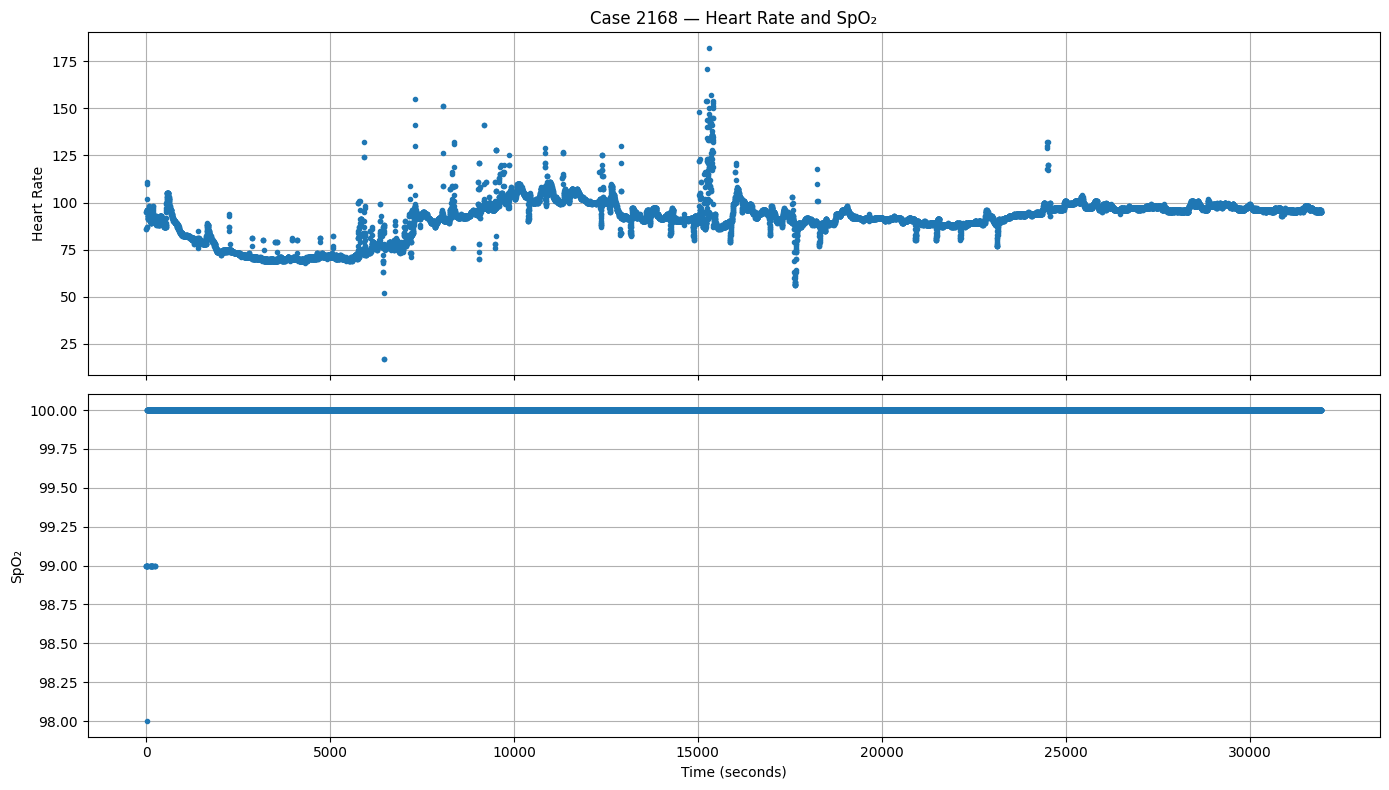

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Heart rate
axes[0].plot(
    working_df["time_sec"],
    working_df["heart_rate"],
    marker=".",
    linestyle="None"
)
axes[0].set_ylabel("Heart Rate")
axes[0].set_title("Case 2168 — Heart Rate and SpO₂")
axes[0].grid(True)

# SpO2
axes[1].plot(
    working_df["time_sec"],
    working_df["spo2"],
    marker=".",
    linestyle="None"
)
axes[1].set_ylabel("SpO₂")
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# STEP: Patient-Specific Anomaly Detection
# ==========================================

# Work on a copy
anomaly_df = working_df.copy()

# Calculate rolling median (patient's local baseline)
window = 300

anomaly_df["HR_baseline"] = (
    anomaly_df["heart_rate"]
    .rolling(window=window, min_periods=30)
    .median()
)

anomaly_df["SpO2_baseline"] = (
    anomaly_df["spo2"]
    .rolling(window=window, min_periods=30)
    .median()
)

# Calculate deviation from baseline
anomaly_df["HR_deviation"] = (
    abs(anomaly_df["heart_rate"] - anomaly_df["HR_baseline"])
)

anomaly_df["SpO2_deviation"] = (
    abs(anomaly_df["spo2"] - anomaly_df["SpO2_baseline"])
)

print("Anomaly analysis created successfully!")

anomaly_df[
    [
        "time_sec",
        "heart_rate",
        "HR_baseline",
        "HR_deviation",
        "spo2",
        "SpO2_baseline",
        "SpO2_deviation"
    ]
].head(20)

Anomaly analysis created successfully!


,time_sec,heart_rate,HR_baseline,HR_deviation,spo2,SpO2_baseline,SpO2_deviation
0,4,95.0,NaN,NaN,99.0,NaN,NaN
1,6,95.0,NaN,NaN,99.0,NaN,NaN
2,8,86.0,NaN,NaN,99.0,NaN,NaN
3,10,86.0,NaN,NaN,99.0,NaN,NaN
4,12,87.0,NaN,NaN,99.0,NaN,NaN
5,14,87.0,NaN,NaN,100.0,NaN,NaN
6,16,96.0,NaN,NaN,100.0,NaN,NaN
7,18,96.0,NaN,NaN,99.0,NaN,NaN
8,20,96.0,NaN,NaN,100.0,NaN,NaN
9,22,95.0,NaN,NaN,100.0,NaN,NaN


In [27]:
# ==========================================
# STEP 3: Improved Anomaly Thresholds
# ==========================================

# Use a high percentile of the observed deviations
# instead of median deviation.

hr_threshold = anomaly_df["HR_deviation"].quantile(0.99)

spo2_threshold = max(
    anomaly_df["SpO2_deviation"].quantile(0.99),
    0.5
)

# Flag unusual changes
anomaly_df["HR_anomaly"] = (
    anomaly_df["HR_deviation"] > hr_threshold
)

anomaly_df["SpO2_anomaly"] = (
    anomaly_df["SpO2_deviation"] > spo2_threshold
)

# Combined anomaly flag
anomaly_df["Anomaly"] = (
    anomaly_df["HR_anomaly"] |
    anomaly_df["SpO2_anomaly"]
)

print("Improved HR threshold:", round(hr_threshold, 2))
print("Improved SpO2 threshold:", round(spo2_threshold, 2))

print("Total anomaly points:",
      int(anomaly_df["Anomaly"].sum()))

print("Anomaly percentage:",
      round(anomaly_df["Anomaly"].mean() * 100, 2), "%")

Improved HR threshold: 21.0
Improved SpO2 threshold: 0.5
Total anomaly points: 176
Anomaly percentage: 1.1 %


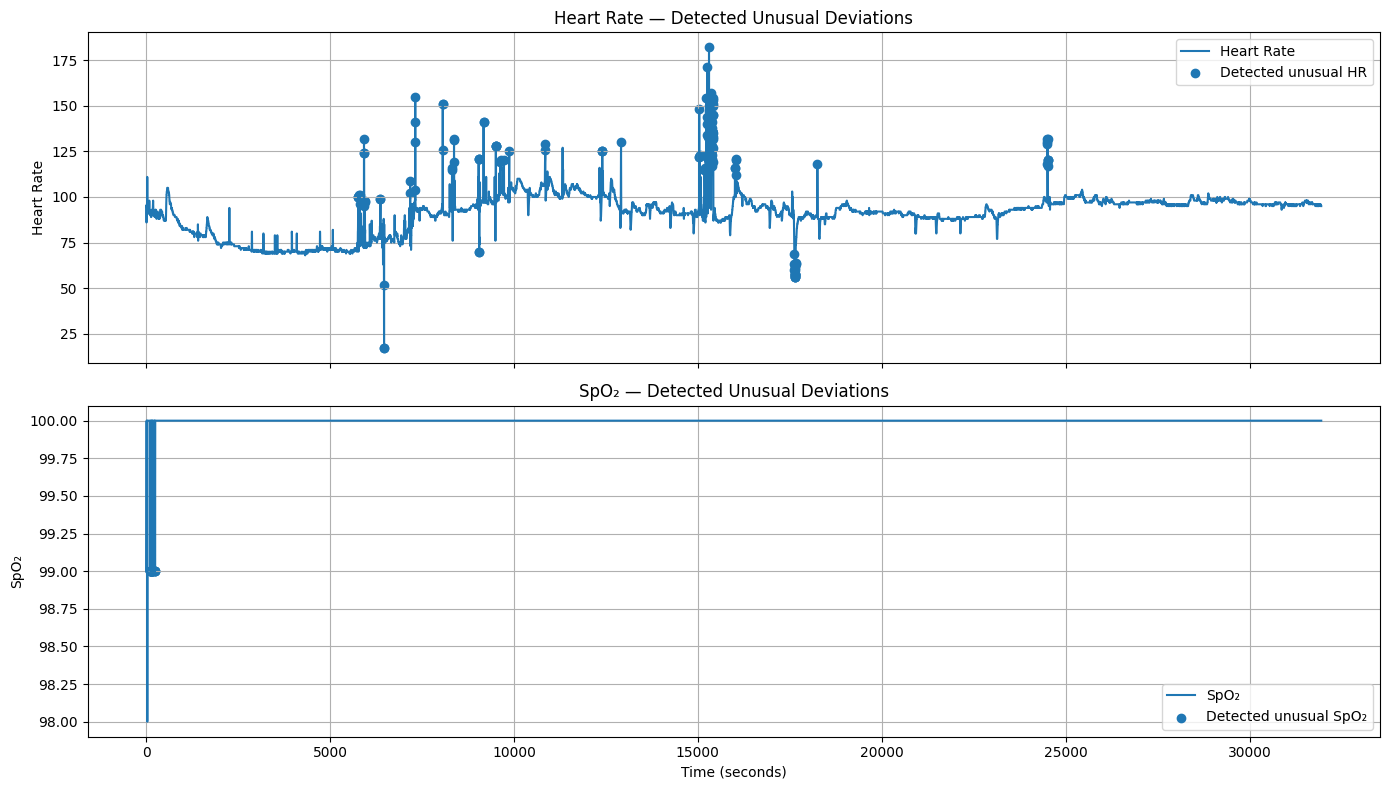

In [28]:
# ==========================================
# STEP 4: Visualize Detected Anomalies
# ==========================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Heart Rate
axes[0].plot(
    anomaly_df["time_sec"],
    anomaly_df["heart_rate"],
    label="Heart Rate"
)

hr_points = anomaly_df[anomaly_df["HR_anomaly"]]

axes[0].scatter(
    hr_points["time_sec"],
    hr_points["heart_rate"],
    label="Detected unusual HR"
)

axes[0].set_ylabel("Heart Rate")
axes[0].set_title("Heart Rate — Detected Unusual Deviations")
axes[0].grid(True)
axes[0].legend()

# SpO2
axes[1].plot(
    anomaly_df["time_sec"],
    anomaly_df["spo2"],
    label="SpO₂"
)

spo2_points = anomaly_df[anomaly_df["SpO2_anomaly"]]

axes[1].scatter(
    spo2_points["time_sec"],
    spo2_points["spo2"],
    label="Detected unusual SpO₂"
)

axes[1].set_ylabel("SpO₂")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_title("SpO₂ — Detected Unusual Deviations")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# STEP 5: Identify Sustained Anomalies
# ==========================================

# Count consecutive anomaly points
anomaly_df["anomaly_group"] = (
    anomaly_df["Anomaly"] != anomaly_df["Anomaly"].shift()
).cumsum()

anomaly_periods = (
    anomaly_df[anomaly_df["Anomaly"]]
    .groupby("anomaly_group")
    .agg(
        start_time=("time_sec", "min"),
        end_time=("time_sec", "max"),
        points=("Anomaly", "size")
    )
    .reset_index(drop=True)
)

# Duration in seconds
anomaly_periods["duration_sec"] = (
    anomaly_periods["end_time"] -
    anomaly_periods["start_time"]
)

print("Total anomaly periods:", len(anomaly_periods))

print("\nLongest anomaly periods:")
print(
    anomaly_periods
    .sort_values("points", ascending=False)
    .head(10)
)

Total anomaly periods: 43

Longest anomaly periods:
    start_time  end_time  points  duration_sec
37       15364     15420      29            56
40       17624     17658      18            34
36       15334     15354      11            20
42       24501     24517       9            16
31       15254     15266       7            12
32       15274     15284       6            10
1          140       150       6            10
34       15298     15306       5             8
13        7315      7321       4             6
8         5923      5929       4             6


In [30]:
# ==========================================
# STEP 6: Calculate Anomaly Severity Score
# ==========================================

# Normalize deviations against their thresholds
anomaly_df["HR_score"] = (
    anomaly_df["HR_deviation"] / hr_threshold
)

anomaly_df["SpO2_score"] = (
    anomaly_df["SpO2_deviation"] / spo2_threshold
)

# Combined score
anomaly_df["anomaly_score"] = (
    anomaly_df["HR_score"] +
    anomaly_df["SpO2_score"]
) / 2

# Keep the score non-negative
anomaly_df["anomaly_score"] = (
    anomaly_df["anomaly_score"].clip(lower=0)
)

print("Anomaly score created successfully!")

print(
    anomaly_df["anomaly_score"].describe()
)

Anomaly score created successfully!
count    15930.000000
mean         0.060805
std          0.116815
min          0.000000
25%          0.000000
50%          0.023810
75%          0.071429
max          2.166667
Name: anomaly_score, dtype: float64


In [31]:
# ==========================================
# STEP 7: Rank the Most Unusual Observations
# ==========================================

top_anomalies = (
    anomaly_df[
        anomaly_df["Anomaly"]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    .head(20)
)

print("Top 20 unusual observations:")
print(
    top_anomalies[
        [
            "time_sec",
            "heart_rate",
            "HR_baseline",
            "HR_deviation",
            "spo2",
            "SpO2_baseline",
            "SpO2_deviation",
            "anomaly_score"
        ]
    ].to_string(index=False)
)

Top 20 unusual observations:
 time_sec  heart_rate  HR_baseline  HR_deviation  spo2  SpO2_baseline  SpO2_deviation  anomaly_score
    15304       182.0         91.0          91.0 100.0          100.0             0.0       2.166667
    15260       171.0         91.0          80.0 100.0          100.0             0.0       1.904762
     7317       155.0         80.0          75.0 100.0          100.0             0.0       1.785714
    15352       157.0         91.0          66.0 100.0          100.0             0.0       1.571429
    15234       154.0         91.0          63.0 100.0          100.0             0.0       1.500000
    15254       154.0         91.0          63.0 100.0          100.0             0.0       1.500000
    15412       154.0         92.5          61.5 100.0          100.0             0.0       1.464286
     5923       132.0         71.0          61.0 100.0          100.0             0.0       1.452381
     7315       141.0         80.0          61.0 100.0        

In [32]:
# ==========================================
# STEP 8: Anomaly Summary
# ==========================================

summary = {
    "Case ID": case_id,
    "Total observations": len(anomaly_df),
    "Anomaly observations": int(anomaly_df["Anomaly"].sum()),
    "Anomaly percentage": round(
        anomaly_df["Anomaly"].mean() * 100, 2
    ),
    "HR anomalies": int(anomaly_df["HR_anomaly"].sum()),
    "SpO2 anomalies": int(anomaly_df["SpO2_anomaly"].sum()),
    "HR threshold": hr_threshold,
    "SpO2 threshold": spo2_threshold
}

summary_df = pd.DataFrame(
    [summary]
)

summary_df

,Case ID,Total observations,Anomaly observations,Anomaly percentage,HR anomalies,SpO2 anomalies,HR threshold,SpO2 threshold
0,2168,15959,176,1.1,158,18,21.0,0.5


In [33]:
summary_df

,Case ID,Total observations,Anomaly observations,Anomaly percentage,HR anomalies,SpO2 anomalies,HR threshold,SpO2 threshold
0,2168,15959,176,1.1,158,18,21.0,0.5


In [34]:
# ==========================================
# STEP 9: Test Anomaly Detection Across Cases
# ==========================================

results = []

for cid in selected_case_ids:

    # Load case
    case_data = vitaldb.load_case(
        cid,
        selected_tracks,
        1
    )

    temp_df = pd.DataFrame(
        case_data,
        columns=columns
    )

    temp_df["time_sec"] = np.arange(len(temp_df))

    # Keep simultaneous HR + SpO2 measurements
    temp_df = temp_df.dropna(
        subset=["heart_rate", "spo2"]
    ).reset_index(drop=True)

    # Need enough observations for rolling baseline
    if len(temp_df) < 100:
        continue

    # Rolling baselines
    temp_df["HR_baseline"] = (
        temp_df["heart_rate"]
        .rolling(window=300, min_periods=30)
        .median()
    )

    temp_df["SpO2_baseline"] = (
        temp_df["spo2"]
        .rolling(window=300, min_periods=30)
        .median()
    )

    # Deviations
    temp_df["HR_deviation"] = abs(
        temp_df["heart_rate"] -
        temp_df["HR_baseline"]
    )

    temp_df["SpO2_deviation"] = abs(
        temp_df["spo2"] -
        temp_df["SpO2_baseline"]
    )

    # Case-specific thresholds
    hr_thr = temp_df["HR_deviation"].quantile(0.99)

    spo2_thr = max(
        temp_df["SpO2_deviation"].quantile(0.99),
        0.5
    )

    # Detect unusual observations
    temp_df["Anomaly"] = (
        (temp_df["HR_deviation"] > hr_thr) |
        (temp_df["SpO2_deviation"] > spo2_thr)
    )

    results.append({
        "case_id": cid,
        "usable_observations": len(temp_df),
        "HR_threshold": round(hr_thr, 2),
        "SpO2_threshold": round(spo2_thr, 2),
        "anomaly_points": int(temp_df["Anomaly"].sum()),
        "anomaly_percentage": round(
            temp_df["Anomaly"].mean() * 100, 2
        )
    })

results_df = pd.DataFrame(results)

results_df

,case_id,usable_observations,HR_threshold,SpO2_threshold,anomaly_points,anomaly_percentage
0,5,10237,7.0,4.0,148,1.45
1,917,7633,29.0,2.0,108,1.41
2,945,9668,20.0,1.0,91,0.94
3,985,10989,25.0,1.0,105,0.96
4,2168,15959,21.0,0.5,176,1.10


In [35]:
# ==========================================
# STEP 10: Display Case Comparison
# ==========================================

results_df = results_df.sort_values(
    "anomaly_percentage",
    ascending=False
).reset_index(drop=True)

print("Anomaly Detection Results")
print("=" * 60)

display(results_df)

Anomaly Detection Results


,case_id,usable_observations,HR_threshold,SpO2_threshold,anomaly_points,anomaly_percentage
0,5,10237,7.0,4.0,148,1.45
1,917,7633,29.0,2.0,108,1.41
2,2168,15959,21.0,0.5,176,1.10
3,985,10989,25.0,1.0,105,0.96
4,945,9668,20.0,1.0,91,0.94


In [36]:
# Basic statistics across the five cases

print("Average anomaly percentage:",
      round(results_df["anomaly_percentage"].mean(), 2), "%")

print("Minimum anomaly percentage:",
      round(results_df["anomaly_percentage"].min(), 2), "%")

print("Maximum anomaly percentage:",
      round(results_df["anomaly_percentage"].max(), 2), "%")

Average anomaly percentage: 1.17 %
Minimum anomaly percentage: 0.94 %
Maximum anomaly percentage: 1.45 %


In [37]:
# Create anomaly severity levels

def classify_severity(score):
    if score < 1:
        return "Normal"
    elif score < 2:
        return "Moderate"
    else:
        return "High"


anomaly_df["Severity"] = anomaly_df["anomaly_score"].apply(classify_severity)

print("Severity distribution:")
print(anomaly_df["Severity"].value_counts())

Severity distribution:
Severity
Normal      15861
Moderate       68
High           30
Name: count, dtype: int64


In [38]:
# Save anomaly detection results

output_columns = [
    "time_sec",
    "heart_rate",
    "spo2",
    "HR_baseline",
    "SpO2_baseline",
    "HR_deviation",
    "SpO2_deviation",
    "anomaly_score",
    "Anomaly",
    "Severity"
]

anomaly_results = anomaly_df[output_columns].copy()

anomaly_results.to_csv(
    "case_2168_anomaly_results.csv",
    index=False
)

print("File saved successfully!")
print("Rows:", len(anomaly_results))
print("Columns:", len(anomaly_results.columns))

File saved successfully!
Rows: 15959
Columns: 10


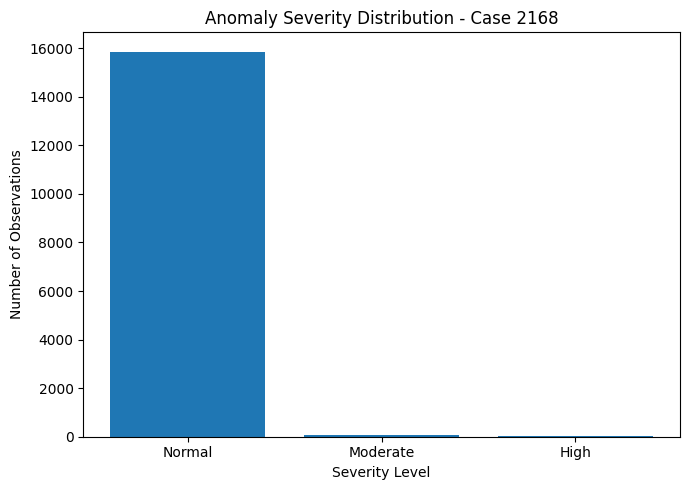

In [39]:
# Visualize anomaly severity distribution

severity_counts = anomaly_df["Severity"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.xlabel("Severity Level")
plt.ylabel("Number of Observations")
plt.title("Anomaly Severity Distribution - Case 2168")

plt.tight_layout()
plt.show()

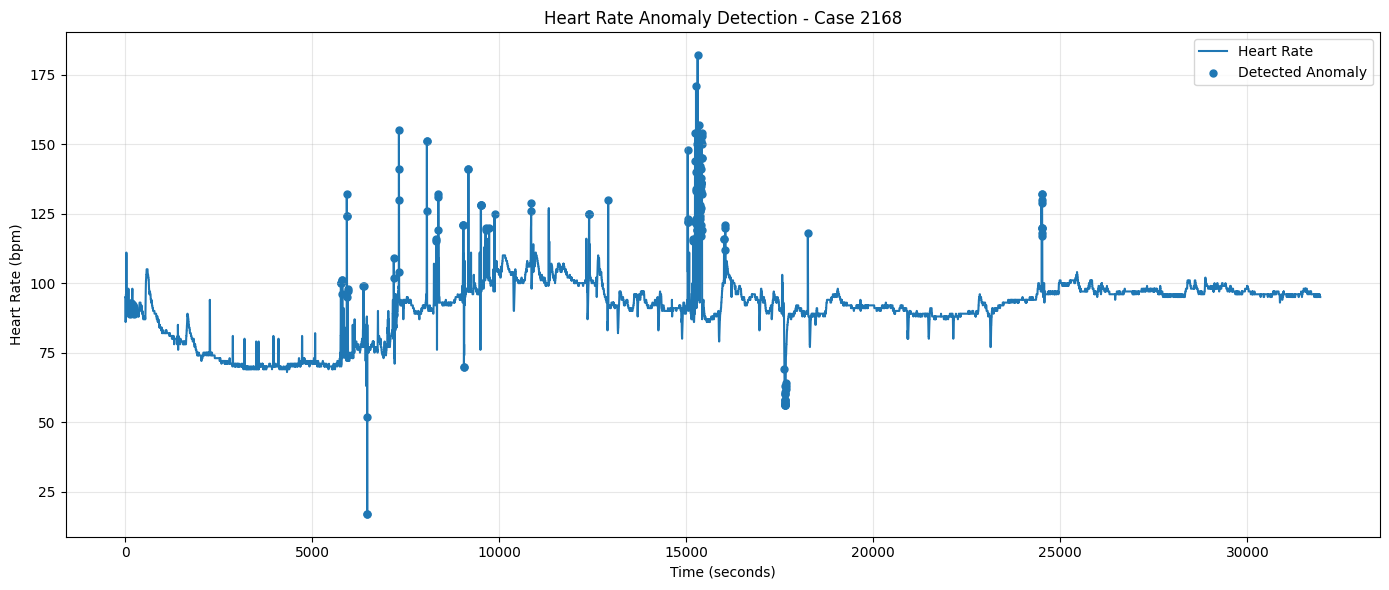

In [40]:
# Final anomaly timeline

plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["time_sec"],
    anomaly_df["heart_rate"],
    label="Heart Rate"
)

anomaly_points = anomaly_df[anomaly_df["Anomaly"]]

plt.scatter(
    anomaly_points["time_sec"],
    anomaly_points["heart_rate"],
    label="Detected Anomaly",
    s=25
)

plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Heart Rate Anomaly Detection - Case 2168")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

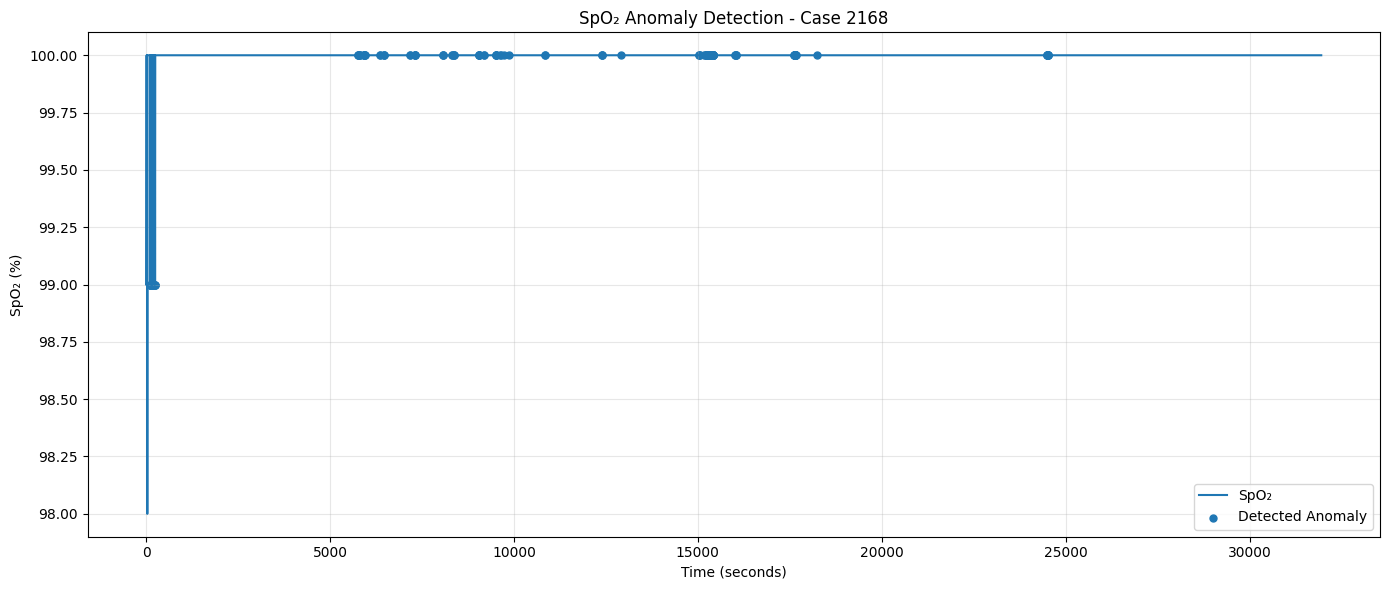

In [41]:
# SpO2 anomaly timeline

plt.figure(figsize=(14, 6))

plt.plot(
    anomaly_df["time_sec"],
    anomaly_df["spo2"],
    label="SpO₂"
)

anomaly_points = anomaly_df[anomaly_df["Anomaly"]]

plt.scatter(
    anomaly_points["time_sec"],
    anomaly_points["spo2"],
    label="Detected Anomaly",
    s=25
)

plt.xlabel("Time (seconds)")
plt.ylabel("SpO₂ (%)")
plt.title("SpO₂ Anomaly Detection - Case 2168")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
from google.colab import files

files.download("case_2168_anomaly_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>